<a href="https://colab.research.google.com/github/1ayse/Analyzing-Marketing-Campaigns-with-pandas/blob/main/Marketing_Campaign_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Was this campaign successful?
  # Conversion Rate : How many people bought the product over all the people contacted for our campaign ?
  # Retention Rate  : Once a user signed up for a subscription, still member after 3-12 months etc. ?

In [ ]:
# Importing Library Modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Read file
marketing = pd.read_csv('marketing.csv')
marketing.head()

/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,user_id,date_served,marketing_channel,variant,converted,language_displayed,language_preferred,age_group,date_subscribed,date_canceled,subscribing_channel,is_retained
0,a100000029,01/01/2018,House Ads,personalization,True,English,English,0-18 years,01/01/2018,NaN,House Ads,True
1,a100000030,01/01/2018,House Ads,personalization,True,English,English,19-24 years,01/01/2018,NaN,House Ads,True
2,a100000031,01/01/2018,House Ads,personalization,True,English,English,24-30 years,01/01/2018,NaN,House Ads,True
3,a100000032,01/01/2018,House Ads,personalization,True,English,English,30-36 years,01/01/2018,NaN,House Ads,True
4,a100000033,01/01/2018,House Ads,personalization,True,English,English,36-45 years,01/01/2018,NaN,House Ads,True


In [6]:
## Conversion Rate ##

# Total number of people contacted
all = marketing['user_id'].nunique()

# Number of people subscribed
sbscrpt = marketing[marketing["converted"] == True]['user_id'].nunique()

# conversion rate
conversion_rate = sbscrpt/all
print("Conversion Rate is", round(conversion_rate*100, 2), "%")

Conversion Rate is 13.89 %


In [8]:
## Retention Rate ##

# Number of people subscribed
sbscrpt = marketing[marketing["converted"] == True]['user_id'].nunique()

# Number of people who remained subscribed
retained = marketing[marketing['is_retained'] == True]['user_id'].nunique()

# Retention rate
retention_rate = retained / sbscrpt
print("Retention Rate is", round(retention_rate *100, 2), "%")

Retention Rate is 66.8 %


In [9]:
## The marketing team wants to determine how effective the campaign was on converting English speakers

# Filter english speakers
english_speakers = marketing[marketing['language_displayed'] == 'English']

# Number of English speakers
total = english_speakers['user_id'].nunique()

# Calculate the number of English speakers who converted
subscribers = english_speakers[english_speakers['converted'] == True]['user_id'].nunique()

# Calculate conversion rate
conversion_rate = subscribers/total
print('English speaker conversion rate:', round(conversion_rate*100,2), '%')

English speaker conversion rate: 12.92 %


In [13]:
## Conversion Rate by Language ##

# Number of user by each language
total = marketing.groupby(['language_displayed'])['user_id'].nunique()

# Number of converted user by each language
subscribers = marketing[marketing['converted'] == True]\
                       .groupby(['language_displayed'])\
                       ['user_id'].nunique()

# Conversion rate for all languages
language_conversion_rate = subscribers/total
print(language_conversion_rate)

language_displayed
Arabic     0.500000
English    0.129167
German     0.716216
Spanish    0.200000
Name: user_id, dtype: float64


In [14]:
## Conversion Rate by Date ##

# Number of user by date
total = marketing.groupby(['date_served'])['user_id'].nunique()

# Number of converted user by date
subscribers = marketing[marketing['converted'] == True]\
                       .groupby(['date_served'])\
                       ['user_id'].nunique()

# Calculate the conversion rate per day
daily_conversion_rate = subscribers/total
print(daily_conversion_rate)

date_served
01/01/2018    0.099448
01/02/2018    0.098930
01/03/2018    0.103448
01/04/2018    0.108359
01/05/2018    0.125392
01/06/2018    0.113636
01/07/2018    0.141818
01/08/2018    0.115385
01/09/2018    0.125000
01/10/2018    0.118694
01/11/2018    0.080645
01/12/2018    0.076412
1/13/18       0.084967
1/14/18       0.085246
1/15/18       0.113429
1/16/18       0.255155
1/17/18       0.219512
1/18/18       0.091195
1/19/18       0.059016
1/20/18       0.067524
1/21/18       0.087336
1/22/18       0.123596
1/23/18       0.122093
1/24/18       0.115789
1/25/18       0.125000
1/26/18       0.090090
1/27/18       0.065625
1/28/18       0.062500
1/29/18       0.059561
1/30/18       0.066246
1/31/18       0.052941
Name: user_id, dtype: float64


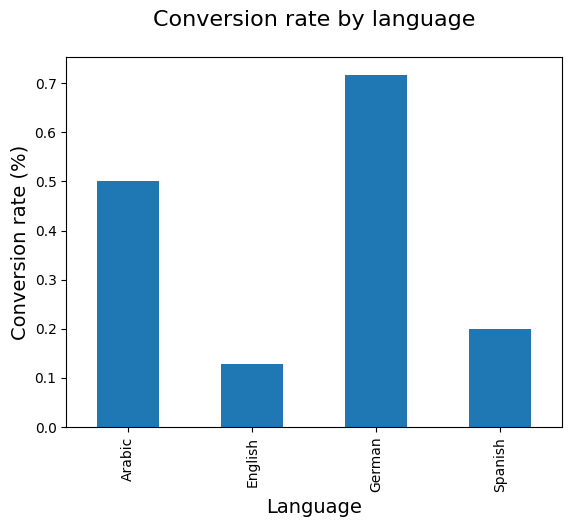

In [15]:
## Plotting Campaign Results ##

language_conversion_rate.plot(kind='bar')
plt.title('Conversion rate by language\n', size = 16)
plt.xlabel('Language', size = 14)
plt.ylabel('Conversion rate (%)', size = 14)

plt.show()

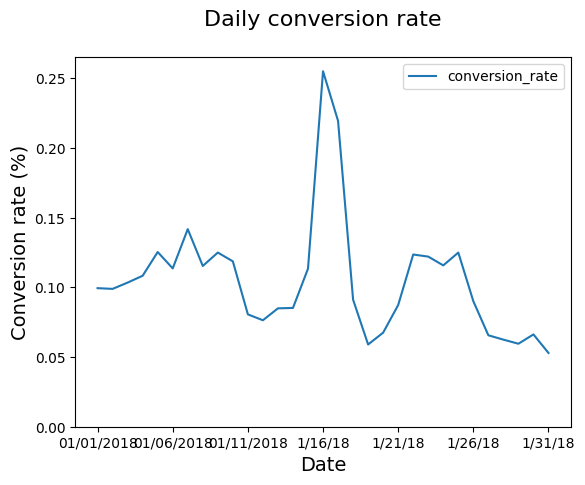

In [20]:

# Reset index to turn the results into a DataFrame
daily_conversion_rate = pd.DataFrame(daily_conversion_rates.reset_index())

# Rename columns
daily_conversion_rate.columns = ['date_served',
                                 'conversion_rate']

# Create a line chart using daily_conversion_rate
daily_conversion_rate.plot('date_served', 'conversion_rate')

plt.title('Daily conversion rate\n', size = 16)
plt.ylabel('Conversion rate (%)', size = 14)
plt.xlabel('Date', size = 14)

# Set the y-axis to begin at 0
plt.ylim(0)

# Display the plot
plt.show()

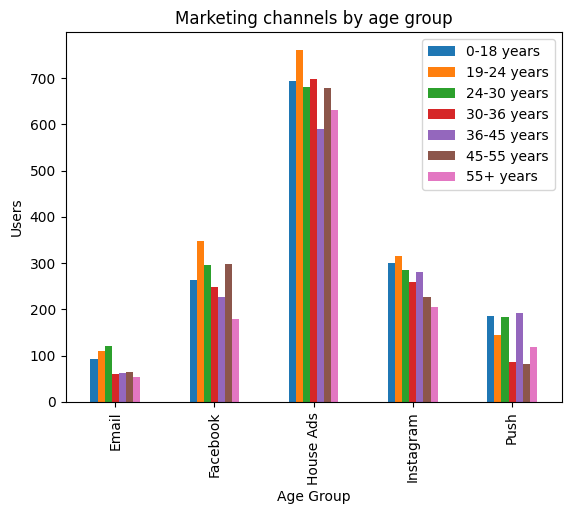

In [21]:
## Marketing channels across age groups ##

channel_age = marketing.groupby(['marketing_channel', 'age_group'])\
                                ['user_id'].count()

# Unstack channel_age and transform it into a DataFrame
channel_age_df = pd.DataFrame(channel_age.unstack(level = 1))

# Plot channel_age
channel_age_df.plot(kind = 'bar')
plt.title('Marketing channels by age group')
plt.xlabel('Age Group')
plt.ylabel('Users')
# Add a legend to the plot
plt.legend(loc = 'upper right',
           labels = channel_age_df.columns.values)
plt.show()

In [25]:
## Grouping and counting by multiple columns ##

retention_total = marketing.groupby(['date_subscribed',
                                     'subscribing_channel'])\
                                       ['user_id'].nunique()

print(retention_total.head())

# Sum the retained subs by subscribing channel and date subscribed
retention_subs = marketing[marketing["is_retained"] == True].groupby(['date_subscribed',
                                       "subscribing_channel"])["user_id"].nunique()

# Print results
retention_subs.head()

date_subscribed  subscribing_channel
01/01/2018       Email                   1
                 Facebook                8
                 House Ads              16
                 Instagram               8
                 Push                    3
Name: user_id, dtype: int64


date_subscribed  subscribing_channel
01/01/2018       Email                   1
                 Facebook                7
                 House Ads              11
                 Instagram               6
                 Push                    3
Name: user_id, dtype: int64

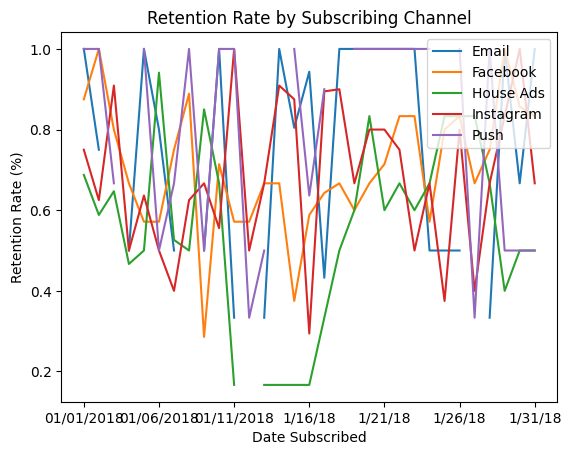

In [26]:
# Divide retained subscribers by total subscribers
retention_rate = retention_subs/retention_total
retention_rate_df = pd.DataFrame(retention_rate.unstack(level=1))

# Plot retention rate
retention_rate_df.plot()

# Add a title, x-label, y-label, legend and display the plot
plt.title('Retention Rate by Subscribing Channel')
plt.xlabel('Date Subscribed')
plt.ylabel('Retention Rate (%)')
plt.legend(loc='upper right', labels=retention_rate_df.columns.values)
plt.show()

In [27]:
## Building conversion function ##
def conversion_rate(dataframe, column_names):
    # Total number of converted users
    column_conv = dataframe[dataframe["converted"] == True].groupby(column_names)["user_id"].nunique()

    # Total number users
    column_total = dataframe.groupby(column_names)["user_id"].nunique()

    # Conversion rate
    conversion_rate = column_conv/column_total

    # Fill missing values with 0
    conversion_rate = conversion_rate.fillna(0)
    return conversion_rate

date_served  age_group  
01/01/2018   0-18 years     0.155172
             19-24 years    0.196721
             24-30 years    0.105263
             30-36 years    0.040816
             36-45 years    0.042553
                              ...   
1/31/18      24-30 years    0.057692
             30-36 years    0.000000
             36-45 years    0.035088
             45-55 years    0.023256
             55+ years      0.026316
Name: user_id, Length: 217, dtype: float64

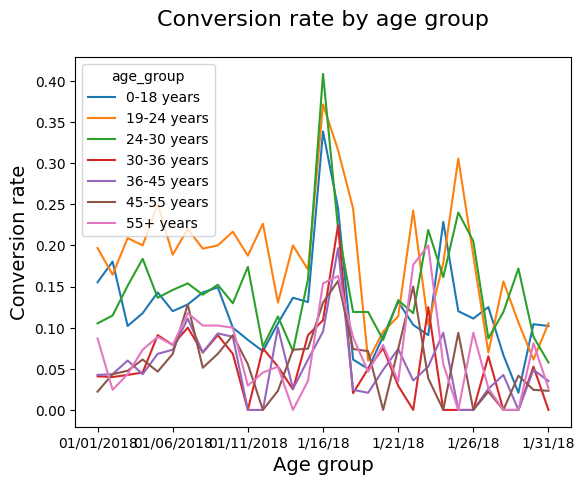

In [28]:
# Calculate conversion rate by age_group
age_group_conv = conversion_rate(marketing, ['date_served', "age_group"])
display(age_group_conv)


# Unstack and create a DataFrame
age_group_df = pd.DataFrame(age_group_conv.unstack(level=1))

# Visualize conversion by age_group
age_group_df.plot()
plt.title('Conversion rate by age group\n', size = 16)
plt.ylabel('Conversion rate', size = 14)
plt.xlabel('Age group', size = 14)
plt.show()

In [29]:
## Plotting function ##

def plotting_conv(dataframe):
    for column in dataframe:
        # Plot column by dataframe's index
        plt.plot(dataframe.index, dataframe[column])  # Ensure you're using plt.plot with index
        plt.title('Daily ' + str(column) + ' conversion rate\n',
                  size = 16)
        plt.ylabel('Conversion rate', size = 14)
        plt.xlabel('Date', size = 14)
        # Show plot
        plt.show()
        plt.clf()

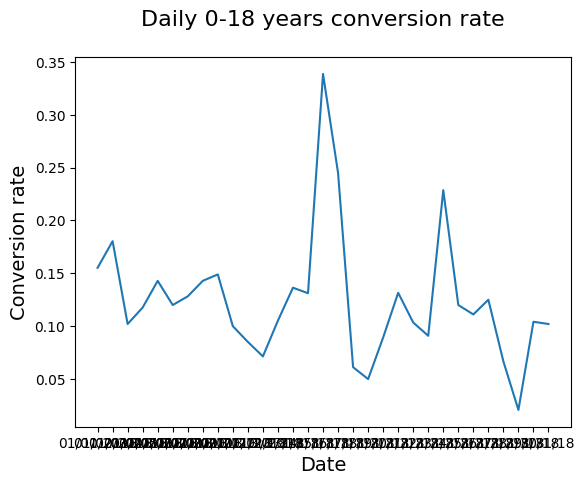

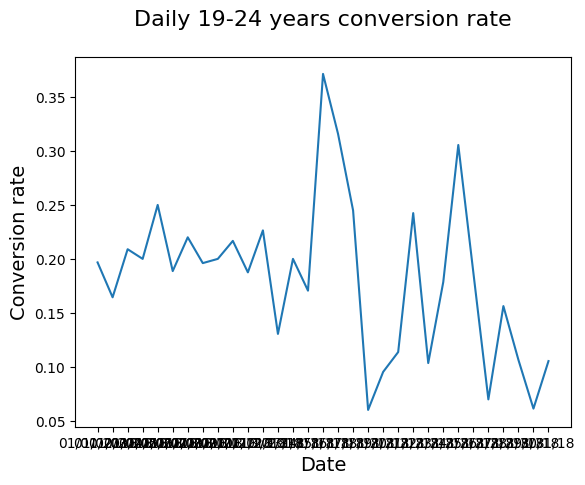

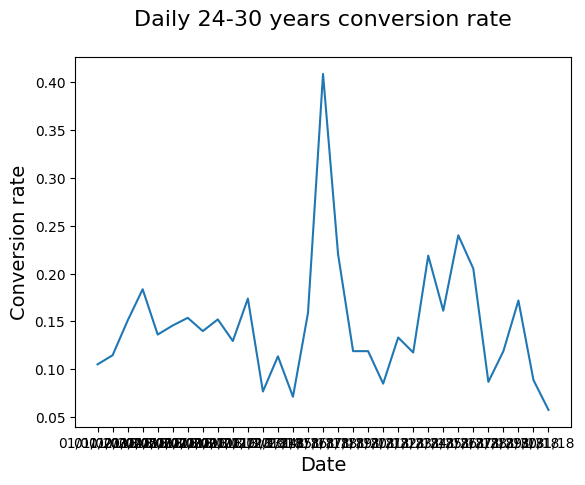

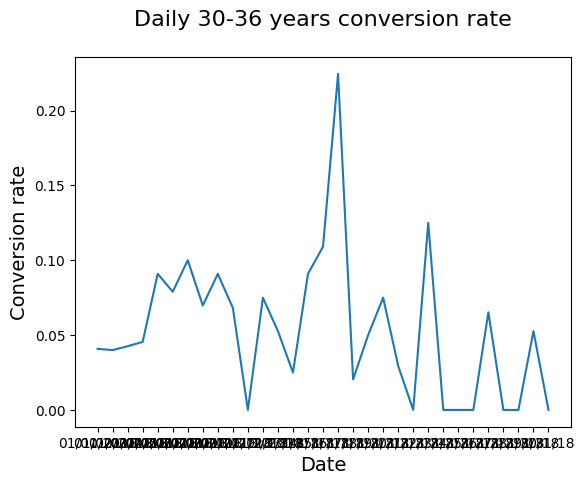

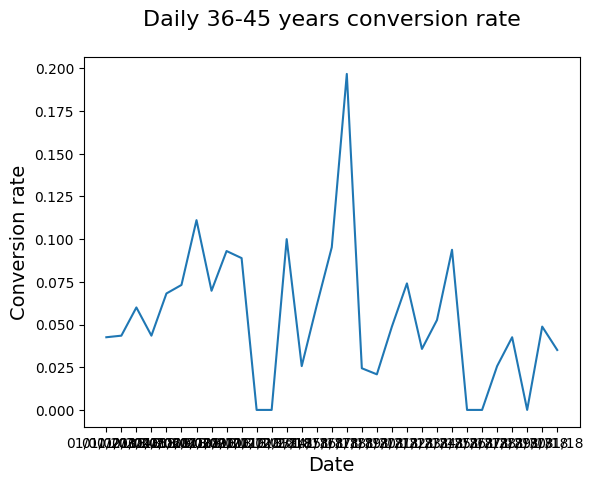

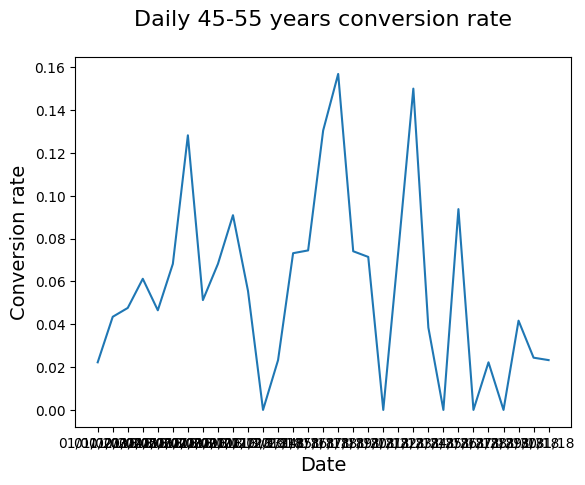

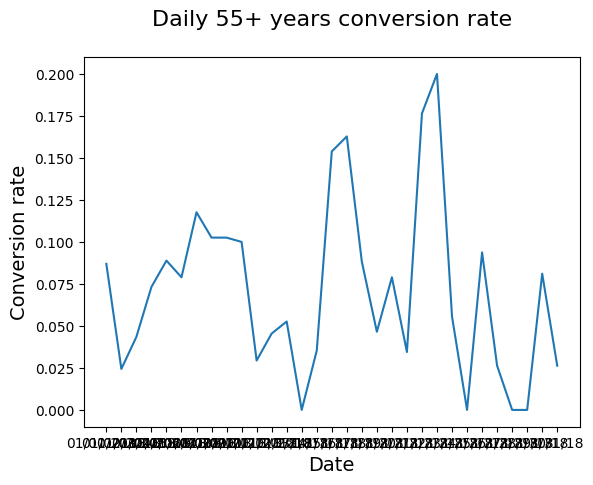

<Figure size 640x480 with 0 Axes>

In [30]:
# Calculate conversion rate by date served and age group
age_group_conv = conversion_rate(marketing, ["date_served", "age_group"])

# Unstack age_group_conv and create a DataFrame
age_group_df = pd.DataFrame(age_group_conv.unstack(level=1))

# Plot the results
plotting_conv(age_group_df)

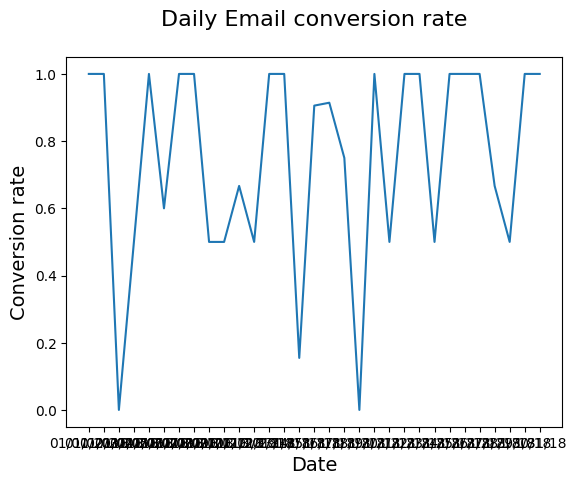

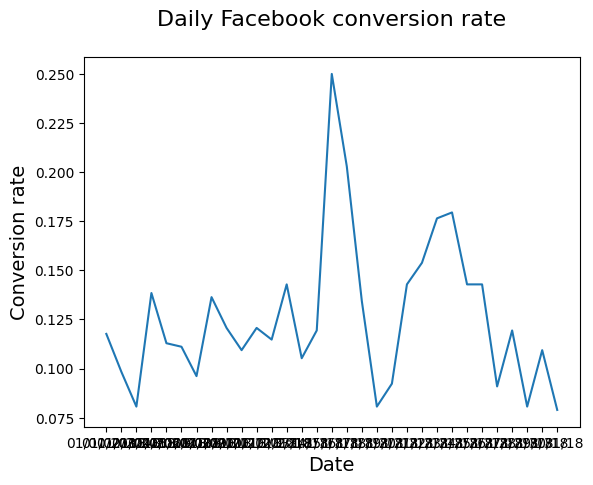

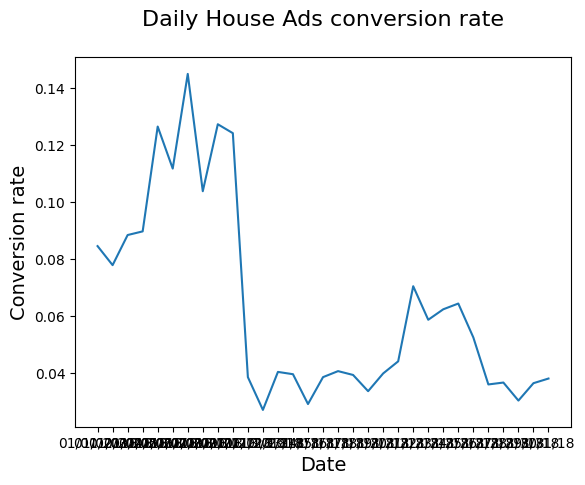

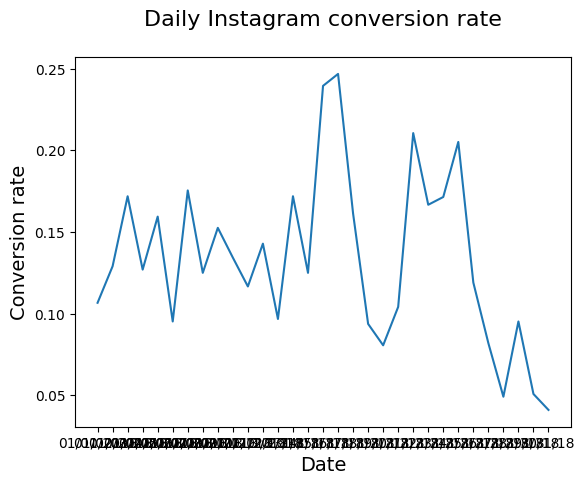

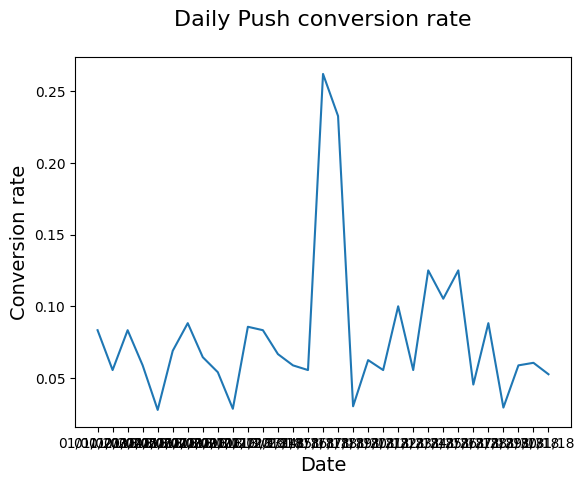

<Figure size 640x480 with 0 Axes>

In [31]:
## Identifying inconsistencies: House ads conversion rate ##

# Calculate conversion rate by date served and channel
daily_conv_channel = conversion_rate(marketing, ['date_served',
                                                 'marketing_channel'])

# Unstack daily_conv_channel and convert it to a DataFrame
daily_conv_channel = pd.DataFrame(daily_conv_channel.unstack(level = 1))

# Plot results of daily_conv_channel
plotting_conv(daily_conv_channel)

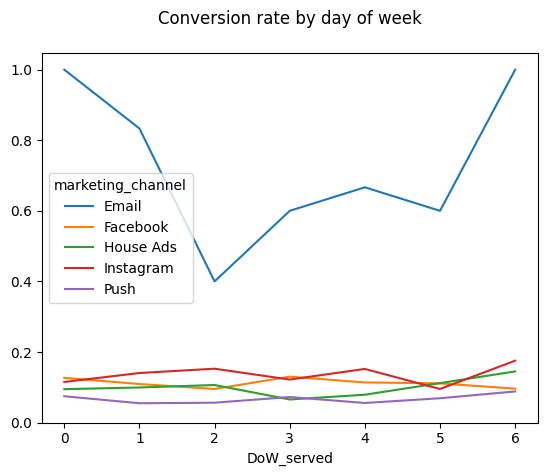

In [33]:
# Check whether users are more likely to convert on weekends compared with weekdays
# and determine if that could be the cause for the changing house ads conversion rate.

# Ensure 'date_served' is datetime
marketing['date_served'] = pd.to_datetime(marketing['date_served'], errors='coerce')

# Add day of week column
marketing['DoW_served'] = marketing['date_served'].dt.dayofweek

# Calculate conversion rate by day of week
DoW_conversion = conversion_rate(marketing, ['DoW_served', 'marketing_channel'])

# Unstack channels
DoW_df = pd.DataFrame(DoW_conversion.unstack(level=1))

# Plot conversion rate by day of week
DoW_df.plot()
plt.title('Conversion rate by day of week\n')
plt.ylim(0)
plt.show()


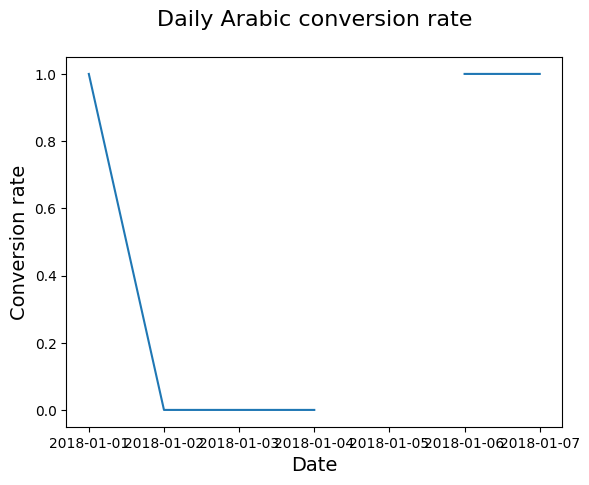

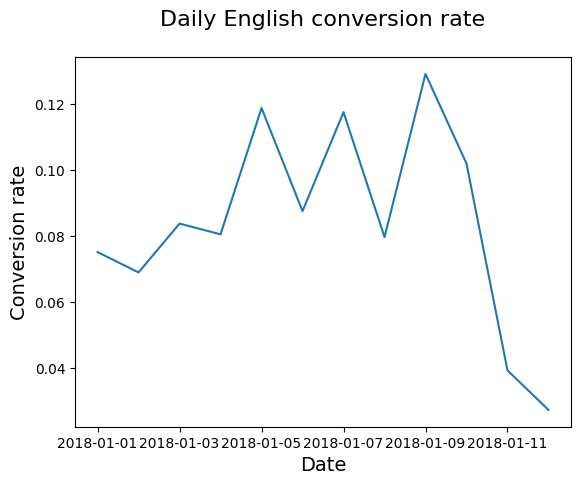

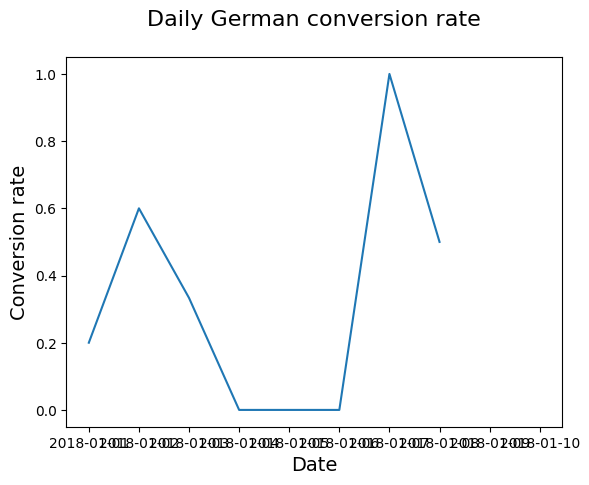

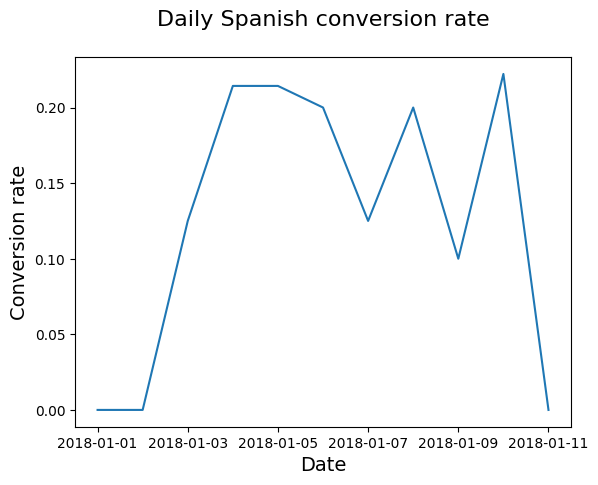

<Figure size 640x480 with 0 Axes>

In [38]:
# Isolate the rows where marketing channel is House Ads
house_ads = marketing[marketing["marketing_channel"] == "House Ads"]

# Calculate conversion by date served, and language displayed
conv_lang_channel = conversion_rate(house_ads, ["date_served", "language_displayed"])

# Unstack conv_lang_channel
conv_lang_df = pd.DataFrame(conv_lang_channel.unstack(level=1))

# Use your plotting function to display results
plotting_conv(conv_lang_df)

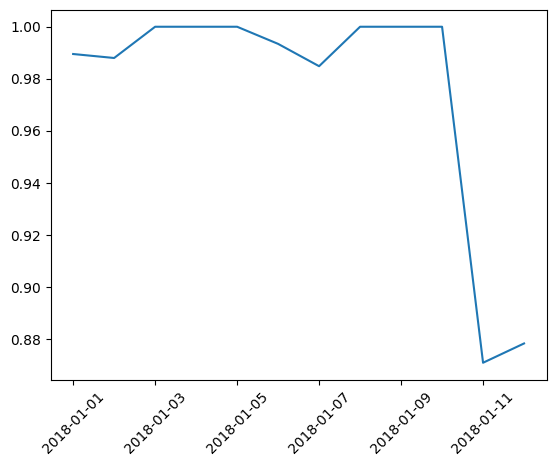

In [40]:
# Divide the count where language is correct by the row sum
language_check_df['pct'] = language_check_df['Yes']/language_check_df.sum(axis=1)

# Plot and show your results
plt.plot(language_check_df.index.values, language_check_df['pct'])
plt.xticks(rotation=45)
plt.show()

In [41]:
## Resolving inconsistencies ##

# We have found out that the language is a problem in House Ads conversion
# How many subscribers we lost as a result of this issue
  # index non-English language conversion rates against English conversion rates in the time period before the language bug arose

##Setting up conversion indexes
# Calculate pre-error conversion rate
house_ads_bug = house_ads[house_ads['date_served'] < '2018-01-11']
lang_conv = conversion_rate(house_ads_bug, "language_displayed")

# Index other language conversion rate against English
spanish_index = lang_conv["Spanish"]/lang_conv["English"]
arabic_index = lang_conv["Arabic"]/lang_conv["English"]
german_index = lang_conv["German"]/lang_conv["English"]

print("Spanish index:", spanish_index)
print("Arabic index:", arabic_index)
print("German index:", german_index)

Spanish index: 1.681924882629108
Arabic index: 5.045774647887324
German index: 4.485133020344287


In [42]:
#  How many subscribers we would have expected had there been no language error

# Group house_ads by date and language
converted = house_ads.groupby(["date_served", "language_preferred"])\
                        .agg({'user_id':'nunique',
                              'converted':'sum'})

# Unstack converted
converted_df = pd.DataFrame(converted.unstack(level=1))

#print results
display(converted_df)

user_id                        converted                 \
language_preferred  Arabic English German Spanish    Arabic English German   
date_served                                                                  
2018-01-01             2.0   171.0    5.0    11.0         2      13      1   
2018-01-02             3.0   200.0    5.0    10.0         0      14      3   
2018-01-03             2.0   179.0    3.0     8.0         0      15      1   
2018-01-04             2.0   149.0    2.0    14.0         0      12      0   
2018-01-05             NaN   143.0    1.0    14.0       NaN      17  False   
2018-01-06             3.0   136.0    2.0    11.0         3      12      0   
2018-01-07             2.0   117.0    2.0    10.0         2      14      2   
2018-01-08             NaN   138.0    6.0    10.0       NaN      11      3   
2018-01-09             NaN   147.0    NaN    10.0       NaN      19    NaN   
2018-01-10             NaN   147.0    4.0    18.0       NaN      15      2   
2018-01-11             7.0   133.0    2.0    13.0         0       6      0   
2018-01-12             3.0   129.0    4.0    11.0         0       3      0   

                            
language_preferred Spanish  
date_served                 
2018-01-01               0  
2018-01-02               0  
2018-01-03               1  
2018-01-04               3  
2018-01-05               3  
2018-01-06               2  
2018-01-07               1  
2018-01-08               2  
2018-01-09               1  
2018-01-10               4  
2018-01-11               0  
2018-01-12               1

In [45]:
#   Build out a DataFrame that will estimate what daily conversion rates should have been if users were being served the correct language
# Create English conversion rate column for affected period
converted_df['english_conv_rate'] = converted_df.loc["2018-01-11":"2018-01-31"][("converted"), ("English")]

# Create expected conversion rates for each language
converted_df['expected_spanish_rate'] = converted_df['english_conv_rate'] * spanish_index
converted_df['expected_arabic_rate'] = converted_df['english_conv_rate'] * arabic_index
converted_df['expected_german_rate'] = converted_df['english_conv_rate'] * german_index

# Multiply number of users by the expected conversion rate
converted_df['expected_spanish_conv'] = converted_df['expected_spanish_rate'] * converted_df[("user_id"), ("Spanish")] /100
converted_df['expected_arabic_conv'] = converted_df['expected_arabic_rate'] *  converted_df[("user_id"), ("Arabic")] /100
converted_df['expected_german_conv'] = converted_df['expected_german_rate'] *  converted_df[("user_id"), ("German")] /100

In [49]:
# Use .loc to slice only the relevant dates
converted_df = converted_df.loc['2018-01-11':'2018-01-31']

# Sum expected subscribers for each language
expected_subs = converted_df["expected_spanish_conv"].sum() + converted_df["expected_arabic_conv"].sum() + converted_df["expected_german_conv"].sum()

# Calculate how many subscribers we actually got
actual_subs = converted_df[('converted','Arabic')].agg('sum') + converted_df[('converted','Spanish')].agg('sum') + converted_df[('converted','German')].agg('sum')

# Subtract how many subscribers we got despite the bug
lost_subs = expected_subs - actual_subs
print(lost_subs)

4.516713615023473
